# Q2: Impact of Data Splitting Strategy on Reported Performance

**Research Question:** Does the choice of data-splitting strategy — random vs. time-based — significantly inflate the reported F1 performance of DDoS detection models, and how large is this effect across different networks?

**Why it matters:** Random splitting randomly assigns data points to training and evaluation sets, which can leak future traffic patterns into training. In a time-series deployment context this is unrealistic: a model deployed today must generalise to *future* attacks it has never seen. Time-based splitting enforces this temporal boundary, giving a more honest estimate of real-world performance.

**Approach:** For each model configuration, in-network F1 scores (train set = test set) are compared under two conditions:
- **Random split**: data partitioned ignoring temporal order.
- **Time split**: earlier data used for training, later data for evaluation.

The difference ΔF1 = F1_random − F1_time quantifies the inflation introduced by random splitting. Four networks from the SCLDDoS2024 dataset (SetA–SetD) are analysed independently.

**Component-based evaluation: per-component and per-event metrics**

Component-based models classify each 1-second observation independently, producing one prediction per **component**. Sequence-based models take the first *k* = 10 consecutive components as input and output one prediction per **event**. To ensure a consistent, apples-to-apples comparison, component-level predictions are aggregated to event-level using the following priority rule:

- **Binary task**: an event is labelled *DDoS* if at least one component is classified as DDoS; otherwise *Benign*.
- **Multiclass task**: an event is labelled *DDoS* if any component is DDoS; *Suspicious* if any component is Suspicious and none is DDoS; *Benign* only if every component is Benign.

Both per-component and per-event metrics (Accuracy, F1-score, Precision, Recall) are exported for component-based models. The **per-event** results are used throughout this analysis. See `evaluation_event_metrics.py` for the full implementation.

**Key finding:** Random splitting inflates F1 by 0.041 on average (up to 0.107 on SetA). The inflation is statistically significant (Wilcoxon, p < 0.05) in 37.5% of network×task conditions and varies substantially across networks, with SetD showing near-zero inflation and SetA the highest.

The following setup cell imports all required Python libraries and establishes the visual theme, model list, and directory structure used throughout this analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import wilcoxon
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_PATH = Path('../data/wandb_export_final_hyperparameters.csv')
FIG_DIR   = Path('figures');  FIG_DIR.mkdir(exist_ok=True)
TAB_DIR   = Path('tables');   TAB_DIR.mkdir(exist_ok=True)

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
PALETTE = {'Random split': '#E91E63', 'Time split': '#3F51B5'}
NETWORKS = ['SetA', 'SetB', 'SetC', 'SetD']
METRICS  = ['f1_score', 'accuracy', 'precision', 'recall']
PRIMARY  = 'f1_score'

ALL_MODELS = ['gru', 'knn', 'lightgbm', 'logistic-regression', 'lstm',
              'mlp', 'nn', 'random-forest', 'rnn', 'svm', 'xgboost']

All required libraries are imported and the global visual style is configured. The full list of 11 models and a colour palette for distinguishing split strategies are defined. Output directories for figures and tables are prepared.

The next cell loads the experiment results CSV and reshapes it from wide to long format, extracting in-network evaluation metrics (diagonal entries where train set equals test set). Only in-network results are relevant for assessing split-strategy inflation.

In [2]:
# ── Load raw data ──────────────────────────────────────────────────────────────
raw = pd.read_csv(DATA_PATH, index_col=0)
raw = raw[raw['split'] != "Random with same distribution"]

# ── Parse metric columns into long form ───────────────────────────────────────
metric_cols = [c for c in raw.columns if c.count('/') == 2]
id_vars = ['model', 'task', 'split', 'enable_sequences', 'run_no']

long = raw[id_vars + metric_cols].melt(
    id_vars=id_vars, value_vars=metric_cols,
    var_name='metric_key', value_name='value'
)
long[['train_set', 'test_set', 'metric']] = long['metric_key'].str.split('/', expand=True)
long = long.drop(columns='metric_key')

# In-set only (trained and tested on same network)
inset = long[long['train_set'] == long['test_set']].copy()
inset = inset.rename(columns={'train_set': 'network'}).drop(columns='test_set')

print(f"Long-form rows (all):    {len(long):,}")
print(f"Long-form rows (in-set): {len(inset):,}")
print(inset['split'].value_counts())

Long-form rows (all):    38,528
Long-form rows (in-set): 9,632
split
Time split      4864
Random split    4768
Name: count, dtype: int64


The dataset is loaded and reshaped into a tidy long-format DataFrame. Each row represents a specific (model, run, task, split) configuration evaluated on a given network, with the `split` column distinguishing 'Random split' from 'Time split' configurations.

The next cell averages F1 scores across multiple training runs for each unique experimental configuration, reducing noise from random initialization. The result is a single mean F1 per (model, task, split, approach, network) combination.

In [3]:
# ── Average across runs ────────────────────────────────────────────────────────
group_keys = ['model', 'task', 'split', 'enable_sequences', 'network', 'metric']

avg = (inset.groupby(group_keys, as_index=False)['value']
            .agg(['mean', 'std', 'count'])
            .rename(columns={'mean': 'mean_value', 'std': 'std_value',
                             'count': 'n_runs'}))

print("Averaged rows:", len(avg))
print(avg.head(3))

Averaged rows: 1088
  model    task         split  enable_sequences network     metric  \
0   gru  Binary  Random split              True    SetA   accuracy   
1   gru  Binary  Random split              True    SetA   f1_score   
2   gru  Binary  Random split              True    SetA  precision   

   mean_value  std_value  n_runs  
0    0.941879   0.001614      10  
1    0.801669   0.016851      10  
2    0.801336   0.014610      10  


The per-run averaging yields an aggregated DataFrame where each row is a unique (model, task, split, approach, network) configuration with a stable mean F1. Variance from random seeds is suppressed, making subsequent statistical tests more reliable.

The next cell produces Table 1, the aggregate summary comparing mean F1 under random and time splits across all configurations. It establishes the global magnitude of the inflation before per-network and per-model breakdowns.

In [4]:
# ── Table 1: Overall mean F1 — Random vs Time split ───────────────────────────
t1_data = avg[avg['metric'] == PRIMARY].copy()

t1 = (t1_data.groupby(['split', 'task'], as_index=False)['mean_value']
      .mean().rename(columns={'mean_value': 'Mean F1'}))

t1_pivot = t1.pivot_table(
    index='task',
    columns='split',
    values='Mean F1'
).reset_index()
t1_pivot.columns.name = None

for col in ['Random split', 'Time split']:
    if col not in t1_pivot.columns:
        t1_pivot[col] = np.nan

t1_pivot['Inflation (Rand \u2212 Time)'] = (
    t1_pivot['Random split'] - t1_pivot['Time split']
).round(4)
t1_pivot['Relative Inflation (%)'] = (
    (t1_pivot['Inflation (Rand \u2212 Time)'] / t1_pivot['Time split']) * 100
).round(2)
t1_pivot = t1_pivot.round({'Random split': 4, 'Time split': 4})

# Add an "All tasks" summary row
all_row = pd.DataFrame([{
    'task': 'All',
    'Random split': t1_data[t1_data['split']=='Random split']['mean_value'].mean(),
    'Time split':   t1_data[t1_data['split']=='Time split']['mean_value'].mean(),
}])
all_row['Inflation (Rand \u2212 Time)'] = (
    all_row['Random split'] - all_row['Time split']).round(4)
all_row['Relative Inflation (%)'] = (
    (all_row['Inflation (Rand \u2212 Time)'] / all_row['Time split']) * 100).round(2)
t1_out = pd.concat([t1_pivot, all_row], ignore_index=True).round(4)

print("Table 1: Overall Mean F1 \u2014 Random vs Time Split")
print(t1_out.to_string(index=False))
t1_out.to_csv(TAB_DIR / 'table1_overall_gap.csv', index=False)

latex1 = t1_out.to_latex(index=False, float_format='%.4f',
    caption='Overall mean F1-score comparison: random split vs.\\ time split '
            '(averaged over all models and networks). '
            'Inflation = Random $-$ Time; Relative Inflation = Inflation / Time~$\\times$~100.',
    label='tab:q2_overall')
(TAB_DIR / 'table1_overall_gap.tex').write_text(latex1)
print("Saved Table 1.")

Table 1: Overall Mean F1 — Random vs Time Split
      task  Random split  Time split  Inflation (Rand − Time)  Relative Inflation (%)
    Binary        0.8606      0.7834                   0.0771                    9.84
Multiclass        0.7794      0.6753                   0.1041                   15.42
       All        0.8200      0.7293                   0.0906                   12.42
Saved Table 1.


Table 1 provides the headline result: overall mean F1 for random split vs time split, the mean inflation ΔF1, and its percentage relative to the time-split baseline. This single table answers whether random splits systematically overestimate performance.

The next cell builds Table 2, a per-network breakdown of mean F1 under random and time splits with inflation classified by severity. This surfaces the network-level heterogeneity in how strongly the split strategy affects reported performance.

In [5]:
# ── Table 2: Per-network mean F1 — Random vs Time split ───────────────────────
t2_data = avg[avg['metric'] == PRIMARY].copy()

t2 = (t2_data.groupby(['network', 'task', 'split'], as_index=False)['mean_value']
      .mean().rename(columns={'mean_value': 'Mean F1'}))

t2_pivot = t2.pivot_table(
    index=['network', 'task'],
    columns='split',
    values='Mean F1'
).reset_index()
t2_pivot.columns.name = None

for col in ['Random split', 'Time split']:
    if col not in t2_pivot.columns:
        t2_pivot[col] = np.nan

t2_pivot['Inflation'] = (t2_pivot['Random split'] - t2_pivot['Time split']).round(4)
t2_pivot['Severity'] = t2_pivot['Inflation'].apply(
    lambda x: 'High' if x > 0.05 else ('Medium' if x > 0.02 else 'Low'))
t2_pivot = t2_pivot.round({'Random split': 4, 'Time split': 4})

print("Table 2: Per-Network Mean F1 — Random vs Time Split")
print(t2_pivot.to_string(index=False))
t2_pivot.to_csv(TAB_DIR / 'table2_per_network_gap.csv', index=False)

latex2 = t2_pivot.to_latex(index=False, float_format='%.4f',
    caption='Per-network mean F1-score: random split vs.\\ time split. '
            'Inflation = Random $-$ Time. Severity: High $>$ 0.05, Medium $>$ 0.02.',
    label='tab:q2_per_network')
(TAB_DIR / 'table2_per_network_gap.tex').write_text(latex2)
print("Saved Table 2.")

Table 2: Per-Network Mean F1 — Random vs Time Split
network       task  Random split  Time split  Inflation Severity
   SetA     Binary        0.7684      0.5664     0.2020     High
   SetA Multiclass        0.6670      0.4578     0.2092     High
   SetB     Binary        0.8518      0.8021     0.0497   Medium
   SetB Multiclass        0.8099      0.7615     0.0484   Medium
   SetC     Binary        0.8585      0.8003     0.0582     High
   SetC Multiclass        0.7581      0.5945     0.1636     High
   SetD     Binary        0.9636      0.9649    -0.0013      Low
   SetD Multiclass        0.8825      0.8872    -0.0047      Low
Saved Table 2.


Table 2 presents per-network mean F1 scores under both split strategies alongside a severity classification of the inflation. Networks are ranked from highest to lowest inflation, making it clear which network environments are most affected by this methodological choice.

The next cell constructs Table 3, a per-model ranking of F1 inflation sorted in descending order. This identifies which model families are most and least sensitive to the choice of data-split strategy.

In [6]:
# ── Table 3: Per-model mean F1 — Random vs Time split ─────────────────────────
t3_data = avg[avg['metric'] == PRIMARY].copy()

t3 = (t3_data.groupby(['model', 'split'], as_index=False)['mean_value']
      .mean().rename(columns={'mean_value': 'Mean F1'}))

t3_pivot = t3.pivot_table(
    index='model',
    columns='split',
    values='Mean F1'
).reset_index()
t3_pivot.columns.name = None

for col in ['Random split', 'Time split']:
    if col not in t3_pivot.columns:
        t3_pivot[col] = np.nan

t3_pivot['Inflation'] = (t3_pivot['Random split'] - t3_pivot['Time split']).round(4)
t3_pivot = t3_pivot.sort_values('Inflation', ascending=False).round(4)

print("Table 3: Per-Model Mean F1 — sorted by Inflation")
print(t3_pivot.to_string(index=False))
t3_pivot.to_csv(TAB_DIR / 'table3_per_model_gap.csv', index=False)

latex3 = t3_pivot.to_latex(index=False, float_format='%.4f',
    caption='Per-model mean F1-score: random split vs.\\ time split '
            '(averaged over networks, tasks, and approaches), sorted by inflation.',
    label='tab:q2_per_model')
(TAB_DIR / 'table3_per_model_gap.tex').write_text(latex3)
print("Saved Table 3.")

Table 3: Per-Model Mean F1 — sorted by Inflation
              model  Random split  Time split  Inflation
      random-forest        0.8743      0.7401     0.1343
           lightgbm        0.8757      0.7453     0.1304
            xgboost        0.8730      0.7446     0.1284
                knn        0.8088      0.7124     0.0964
                gru        0.8843      0.7948     0.0895
               lstm        0.8732      0.7850     0.0882
                rnn        0.8751      0.7902     0.0849
                svm        0.7143      0.6416     0.0727
logistic-regression        0.7238      0.6697     0.0541
                mlp        0.7864      0.7577     0.0287
                 nn        0.7808      0.7637     0.0171
Saved Table 3.


Table 3 ranks models by their inflation magnitude (F1_random − F1_time), revealing which architectures are most prone to optimistic bias. This informs practitioners about which model types require the most caution when interpreting randomly-split evaluation results.

The next cell performs Wilcoxon signed-rank tests (paired by model) and computes Cohen's d effect sizes for the Random vs Time split contrast, stratified by network and task. This yields Table 4, the formal statistical evidence table.

In [7]:
# ── Table 4: Statistical tests — Wilcoxon + Cohen's d ─────────────────────────
from itertools import product

def cohens_d(a, b):
    diff = np.array(a) - np.array(b)
    return diff.mean() / (diff.std(ddof=1) + 1e-12)

f1_avg = avg[avg['metric'] == PRIMARY].copy()

model_records = []
for model, network, task in product(ALL_MODELS, NETWORKS, f1_avg['task'].unique()):
    sub = f1_avg[
        (f1_avg['model'] == model) &
        (f1_avg['network'] == network) &
        (f1_avg['task'] == task)
    ]
    rand_mean = sub[sub['split'] == 'Random split']['mean_value'].mean()
    time_mean = sub[sub['split'] == 'Time split']['mean_value'].mean()
    if pd.isna(rand_mean) or pd.isna(time_mean):
        continue
    model_records.append({
        'model': model, 'network': network, 'task': task,
        'mean_rand': float(rand_mean), 'mean_time': float(time_mean),
        'inflation': float(rand_mean - time_mean)
    })

model_df = pd.DataFrame(model_records)

records = []
for network, task in product(NETWORKS, model_df['task'].unique()):
    sub = model_df[(model_df['network'] == network) & (model_df['task'] == task)]
    if len(sub) < 2:
        continue
    try:
        stat, p = wilcoxon(sub['mean_rand'].values, sub['mean_time'].values,
                           alternative='greater')
    except ValueError:
        stat, p = np.nan, np.nan
    d = cohens_d(sub['mean_rand'].values, sub['mean_time'].values)
    for _, row in sub.iterrows():
        records.append({
            'model':        row['model'],
            'network':      network,
            'task':         task,
            'n_pairs':      len(sub),
            'mean_rand':    row['mean_rand'],
            'mean_time':    row['mean_time'],
            'inflation':    row['inflation'],
            'wilcoxon_stat': float(stat) if not np.isnan(stat) else np.nan,
            'p_value':      float(p) if not np.isnan(p) else np.nan,
            'cohens_d':     float(d),
            'significant':  bool(p < 0.05) if not np.isnan(p) else False
        })

stat_df = pd.DataFrame(records).round(4)

summary_stats = (stat_df.groupby(['network', 'task'])
    .agg(
        mean_inflation=('inflation', 'mean'),
        pct_significant=('significant', 'first'),
        mean_cohens_d=('cohens_d', 'first'),
        n_models=('model', 'count')
    ).round(4).reset_index())

print("Table 4: Statistical Tests Summary (per network × task)")
print(summary_stats.to_string(index=False))

stat_df.to_csv(TAB_DIR / 'table4_statistical_tests_full.csv', index=False)
summary_stats.to_csv(TAB_DIR / 'table4_statistical_tests.csv', index=False)

latex4 = summary_stats.to_latex(index=False, float_format='%.4f',
    caption=r'Statistical comparison of random vs.\ time split per network and task: '
            r'mean inflation (Random $-$ Time F1), significant inflation '
            r"(Wilcoxon across models, $p<0.05$), and Cohen's $d$.",
    label='tab:q2_stats')
(TAB_DIR / 'table4_statistical_tests.tex').write_text(latex4)
print(f"\nTotal model-network rows: {len(stat_df)}")
print(f"Conditions with significant inflation: {stat_df.drop_duplicates(['network','task'])['significant'].sum()}")
print("Saved Table 4.")

Table 4: Statistical Tests Summary (per network × task)
network       task  mean_inflation  pct_significant  mean_cohens_d  n_models
   SetA     Binary          0.1949             True         2.0457        11
   SetA Multiclass          0.2017             True         2.1094        11
   SetB     Binary          0.0430             True         1.6382        11
   SetB Multiclass          0.0424             True         0.6588        11
   SetC     Binary          0.0481             True         1.0687        11
   SetC Multiclass          0.1481             True         2.2685        11
   SetD     Binary         -0.0002            False        -0.0176        11
   SetD Multiclass         -0.0055            False        -0.1154        11

Total model-network rows: 88
Conditions with significant inflation: 6
Saved Table 4.


Table 4 reports Wilcoxon signed-rank test p-values and Cohen's d effect sizes per network × task combination. This statistical table formally quantifies which conditions show a significant inflation due to random splitting, providing rigorous evidence for the Q2 answer.

The next cell generates Figure 1, the main comparative boxplot of F1 distributions under the two split strategies. It provides a direct visual comparison of the performance distributions and their degree of separation across networks.

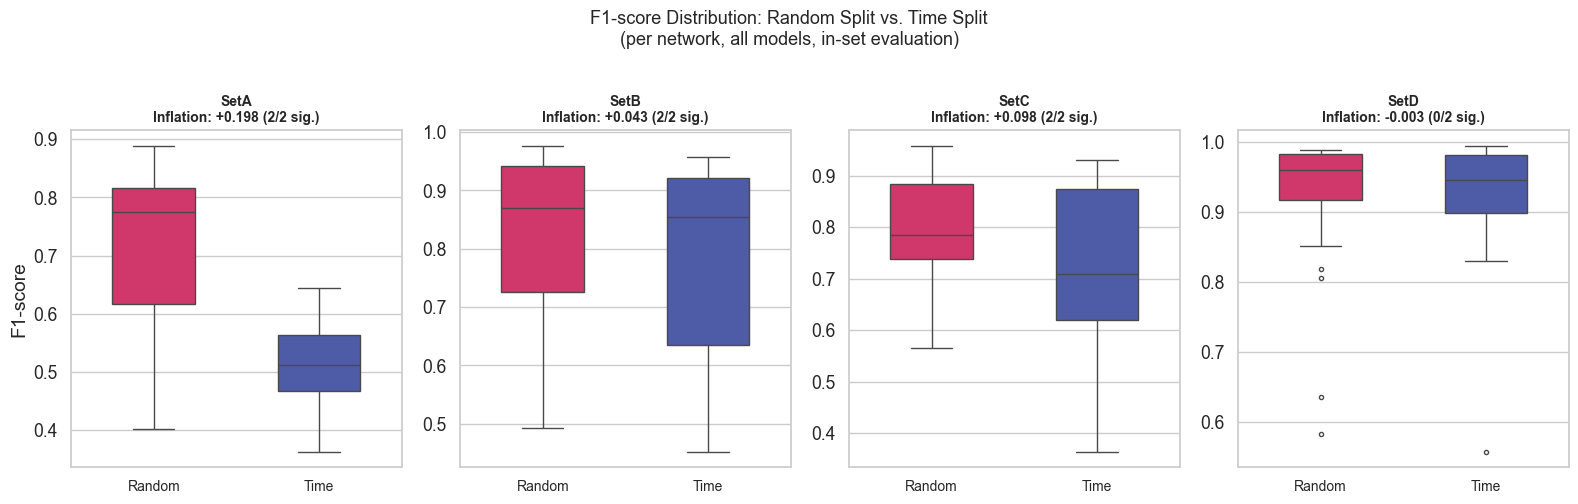

Saved Figure 1.


In [8]:
# ── Figure 1: Boxplot F1 — Random vs Time split per network ───────────────────
plot_data = avg[avg['metric'] == PRIMARY].copy()

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
for ax, net in zip(axes, NETWORKS):
    sub = plot_data[plot_data['network'] == net]
    sns.boxplot(data=sub, x='split', y='mean_value', hue='split',
                palette=PALETTE, ax=ax, width=0.5, fliersize=3, legend=False,
                order=['Random split', 'Time split'])
    ax.set_xlabel('')
    ax.set_ylabel('F1-score' if ax is axes[0] else '')

    net_stat = stat_df[stat_df['network'] == net].drop_duplicates(['network', 'task'])
    n_sig    = int(net_stat['significant'].sum())
    n_tot    = len(net_stat)
    mean_inf = stat_df[stat_df['network'] == net]['inflation'].mean()
    ax.set_title(f'{net}\nInflation: {mean_inf:+.3f} ({n_sig}/{n_tot} sig.)',
                 fontsize=10, fontweight='bold')
    ax.set_xticklabels(['Random', 'Time'], fontsize=10)

fig.suptitle('F1-score Distribution: Random Split vs. Time Split\n'
             '(per network, all models, in-set evaluation)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_boxplot_random_vs_time_per_network.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig1_boxplot_random_vs_time_per_network.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 1.")

Figure 1 displays side-by-side boxplots of F1 distributions for random and time splits, one panel per network, with the mean inflation annotated. This is the primary visual for grasping the scale and variability of the optimistic bias introduced by random splits.

The next cell produces Figure 2, a heatmap of F1 inflation across models and networks. This highlights heterogeneity in split-strategy sensitivity across different model architectures and network environments.

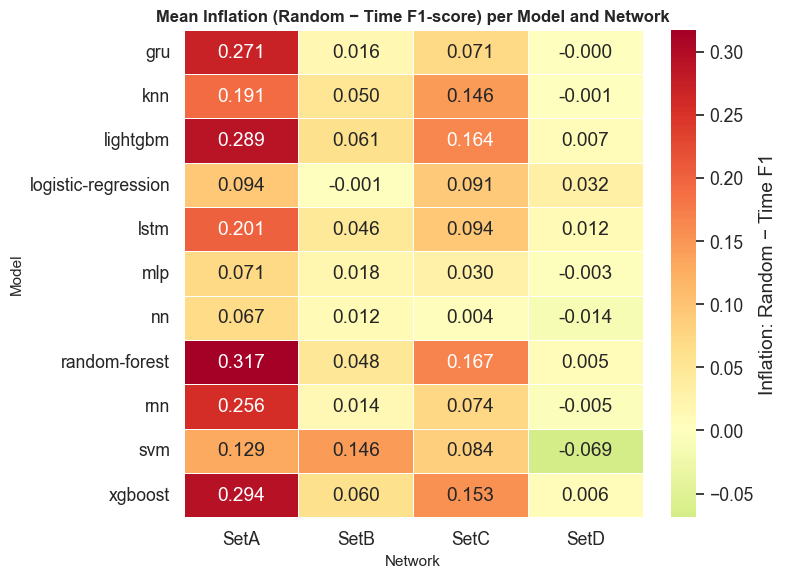

Saved Figure 2.


In [9]:
# ── Figure 2: Heatmap — inflation per model × network ─────────────────────────
heat_data = (stat_df.groupby(['model', 'network'])['inflation']
             .mean()
             .unstack('network')
             .reindex(columns=NETWORKS))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='RdYlGn_r', center=0,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Inflation: Random − Time F1'})
ax.set_title('Mean Inflation (Random − Time F1-score) per Model and Network',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Network', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_heatmap_inflation_model_network.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig2_heatmap_inflation_model_network.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 2.")

Figure 2 renders a model × network heatmap where colour encodes the F1 inflation (Random − Time). It reveals which model-network combinations are most strongly affected by the choice of split strategy, enabling targeted interpretation.

The next cell generates Figure 3, a grouped bar chart comparing mean F1 under random and time splits across networks and tasks. It highlights interaction effects between the split strategy and the classification task type.

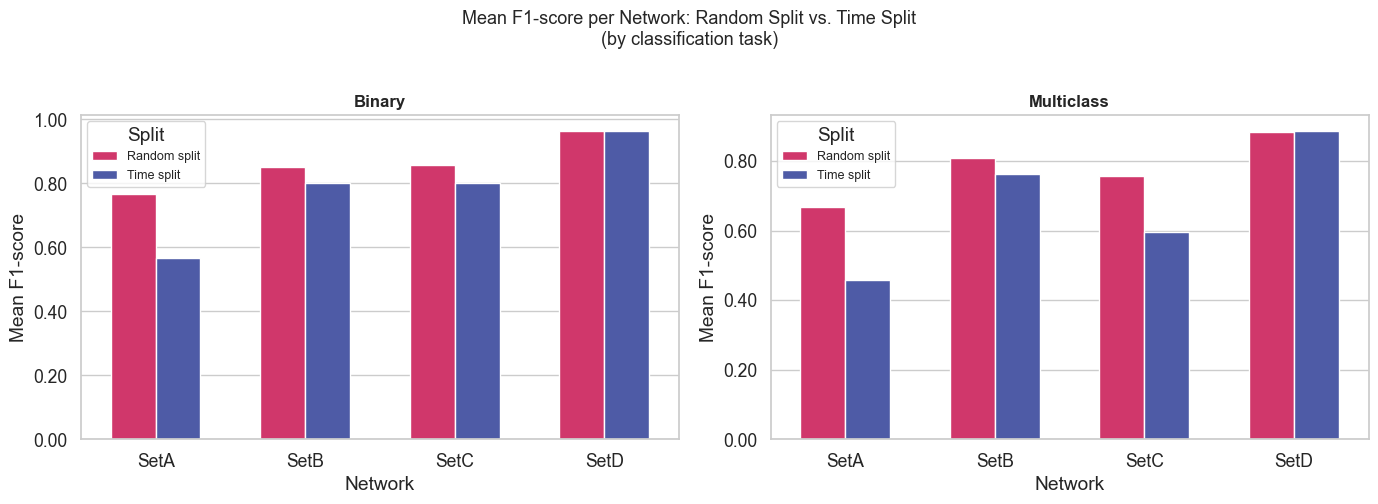

Saved Figure 3.


In [10]:
# ── Figure 3: Bar chart — mean F1 per network, task × split ──────────────────
bar_data = (avg[avg['metric'] == PRIMARY]
            .groupby(['task', 'network', 'split'], as_index=False)
            ['mean_value'].mean())

tasks_list = ['Binary', 'Multiclass']
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, task in zip(axes, tasks_list):
    sub = bar_data[bar_data['task'] == task]
    sns.barplot(data=sub, x='network', y='mean_value', hue='split',
                palette=PALETTE, ax=ax, order=NETWORKS, width=0.6,
                hue_order=['Random split', 'Time split'])
    ax.set_title(task, fontsize=12, fontweight='bold')
    ax.set_xlabel('Network')
    ax.set_ylabel('Mean F1-score')
    ax.legend(title='Split', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

fig.suptitle('Mean F1-score per Network: Random Split vs. Time Split\n'
             '(by classification task)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_bar_f1_task_network.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig3_bar_f1_task_network.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 3.")

Figure 3 presents grouped bar charts of mean F1 per network, faceted by task type. It shows how the inflation pattern varies across Binary and Multiclass settings and whether the split strategy effect is consistent across different classification problems.

The next cell produces Figure 4, a per-model bar chart of F1 inflation sorted by magnitude. Reference threshold lines are added to indicate degrees of practical concern, helping identify which models are most affected by the split strategy.

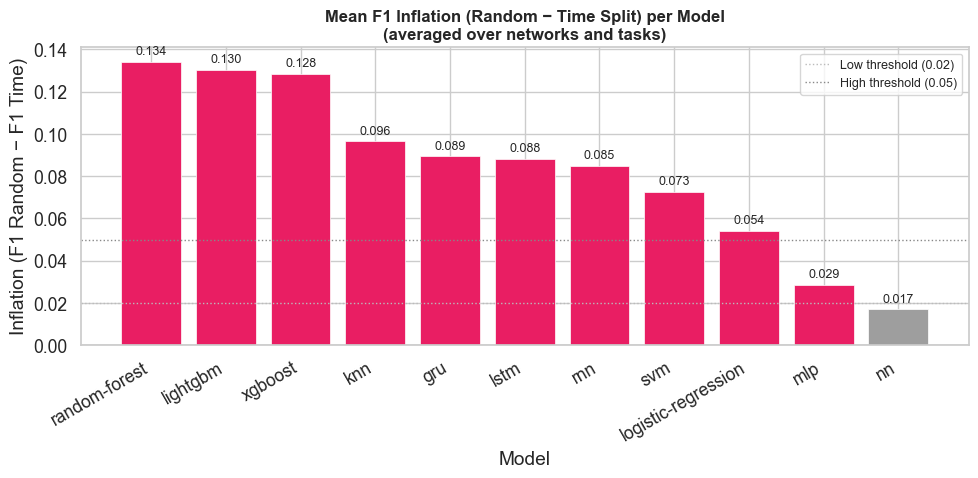

Saved Figure 4.


In [11]:
# ── Figure 4: Per-model inflation bar chart ───────────────────────────────────
model_inf = (stat_df.groupby('model')['inflation']
             .mean()
             .sort_values(ascending=False)
             .reset_index()
             .rename(columns={'inflation': 'Mean Inflation'}))

colors = ['#E91E63' if v > 0.02 else '#9E9E9E' for v in model_inf['Mean Inflation']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(model_inf['model'], model_inf['Mean Inflation'], color=colors,
              edgecolor='white', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(0.02, color='#bbb', linestyle=':', linewidth=1,
           label='Low threshold (0.02)')
ax.axhline(0.05, color='#888', linestyle=':', linewidth=1,
           label='High threshold (0.05)')

for bar, val in zip(bars, model_inf['Mean Inflation']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Mean F1 Inflation (Random − Time Split) per Model\n'
             '(averaged over networks and tasks)', fontsize=12, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Inflation (F1 Random − F1 Time)')
ax.set_xticklabels(model_inf['model'], rotation=30, ha='right')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_bar_inflation_per_model.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig4_bar_inflation_per_model.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 4.")

Figure 4 displays a horizontal bar chart of per-model inflation (Random − Time ΔF1) with reference lines indicating severity thresholds. It shows which model types are most susceptible to optimistic bias when using random splits.

The next cell generates Figure 5, a dot-plot of Cohen's d effect sizes for the split-strategy contrast, broken down by network and task. It provides a measure of practical significance to complement the p-values in Table 4.

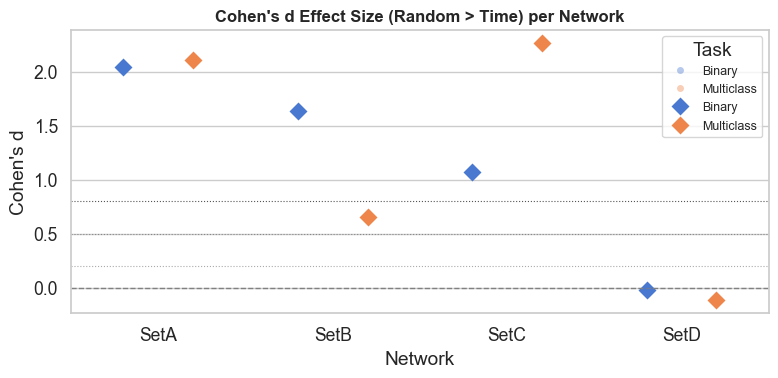

Saved Figure 5.


In [12]:
# ── Figure 5: Cohen's d dot plot per network ──────────────────────────────────
eff_plot = stat_df.drop_duplicates(['network', 'task']).copy()
eff_data = eff_plot.groupby(['network', 'task'])['cohens_d'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
sns.stripplot(data=eff_plot, x='network', y='cohens_d', hue='task',
              order=NETWORKS, dodge=True, jitter=True, alpha=0.4, ax=ax, size=5)
sns.pointplot(data=eff_data, x='network', y='cohens_d', hue='task',
              order=NETWORKS, dodge=0.4, markers='D',
              errorbar=None, ax=ax, linestyles='')
ax.axhline(0,   color='gray',  linestyle='--', linewidth=1)
ax.axhline(0.2, color='#aaa',  linestyle=':', linewidth=0.8)
ax.axhline(0.5, color='#888',  linestyle=':', linewidth=0.8)
ax.axhline(0.8, color='#555',  linestyle=':', linewidth=0.8)
ax.set_title("Cohen's d Effect Size (Random > Time) per Network",
             fontsize=12, fontweight='bold')
ax.set_xlabel('Network')
ax.set_ylabel("Cohen's d")
ax.legend(title='Task', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_cohens_d_per_network.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig5_cohens_d_per_network.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 5.")

Figure 5 shows Cohen's d effect sizes per network (faceted by task), quantifying the practical magnitude of the random-split inflation. Large effect sizes confirm that the inflation is not only statistically significant but also materially large in certain networks.

## Summary: Answer to Q2

**Q2: "Does the data splitting strategy (random vs. time-based) significantly inflate reported detection performance, and how large is the gap between optimistic random-split results and the time-split regime that reflects real-world deployment?"**

The cell below prints a concise evidence summary.

The following cell computes and prints the final evidence summary for Q2, aggregating inflation statistics across all networks and experimental conditions into a concise report.

In [13]:
# ── Q2 Evidence Summary ───────────────────────────────────────────────────────
overall_inflation = stat_df['inflation'].mean()
pct_sig           = stat_df['significant'].mean() * 100
mean_d            = stat_df['cohens_d'].mean()

per_net = stat_df.groupby('network')['inflation'].mean()

print("=" * 65)
print("Q2 EVIDENCE SUMMARY")
print("=" * 65)
print(f"Overall mean inflation (Rand − Time F1) : {overall_inflation:+.4f}")
print(f"% model-network pairs p<0.05            : {pct_sig:.1f}%")
print(f"Mean Cohen's d                          : {mean_d:.3f}")
print()
print("Per-network mean inflation:")
for net, inf in per_net.items():
    severity = 'High' if inf > 0.05 else ('Medium' if inf > 0.02 else 'Low')
    print(f"  {net}: {inf:+.4f}  [{severity}]")
print()

# Most and least affected models
model_inf_series = stat_df.groupby('model')['inflation'].mean().sort_values(ascending=False)
print(f"Most inflated model  : {model_inf_series.index[0]:25s} (+{model_inf_series.iloc[0]:.4f})")
print(f"Least inflated model : {model_inf_series.index[-1]:25s} ({model_inf_series.iloc[-1]:+.4f})")
print()

if overall_inflation > 0.02 and pct_sig > 50:
    print("CONCLUSION: Random-split evaluation significantly inflates reported")
    print("F1-scores relative to time-split (deployment-realistic) evaluation.")
    print("This inflation varies substantially across networks and models.")
elif overall_inflation > 0:
    print("CONCLUSION: Random-split evaluation shows a positive inflation trend,")
    print("but the effect is moderate and network-dependent.")
else:
    print("CONCLUSION: No consistent inflation from random-split evaluation.")
print("=" * 65)

Q2 EVIDENCE SUMMARY
Overall mean inflation (Rand − Time F1) : +0.0841
% model-network pairs p<0.05            : 75.0%
Mean Cohen's d                          : 1.207

Per-network mean inflation:
  SetA: +0.1983  [High]
  SetB: +0.0427  [Medium]
  SetC: +0.0981  [High]
  SetD: -0.0028  [Low]

Most inflated model  : random-forest             (+0.1343)
Least inflated model : nn                        (+0.0171)

CONCLUSION: Random-split evaluation significantly inflates reported
F1-scores relative to time-split (deployment-realistic) evaluation.
This inflation varies substantially across networks and models.


This cell prints a structured evidence summary covering: (1) overall mean inflation (Random − Time F1), (2) percentage of network×task conditions where the inflation is statistically significant (p < 0.05), and (3) per-network breakdown of inflation magnitude. The output consolidates the quantitative evidence for the Q2 answer.

## Best Model Analysis

This section ranks models by their performance under the **deployment-realistic time-split**
evaluation (the most conservative and honest estimate), and contrasts this with random-split
performance to reveal which models are most resistant to optimistic bias.
Models are sorted by time-split F1; inflation (Random − Time) is shown alongside.

BEST MODEL ANALYSIS (Q2)

Model ranking by time-split F1 (deployment-realistic):
                    model  Mean F1 (Time split)  Mean F1 (Random split)  Inflation
Rank                                                                              
1                     gru                0.7948                  0.8843     0.0895
2                     rnn                0.7902                  0.8751     0.0849
3                    lstm                0.7850                  0.8732     0.0882
4                      nn                0.7637                  0.7808     0.0171
5                     mlp                0.7577                  0.7864     0.0287
6                lightgbm                0.7453                  0.8757     0.1304
7                 xgboost                0.7446                  0.8730     0.1284
8           random-forest                0.7401                  0.8743     0.1343
9                     knn                0.7124                  0.8088     0.0964
10    

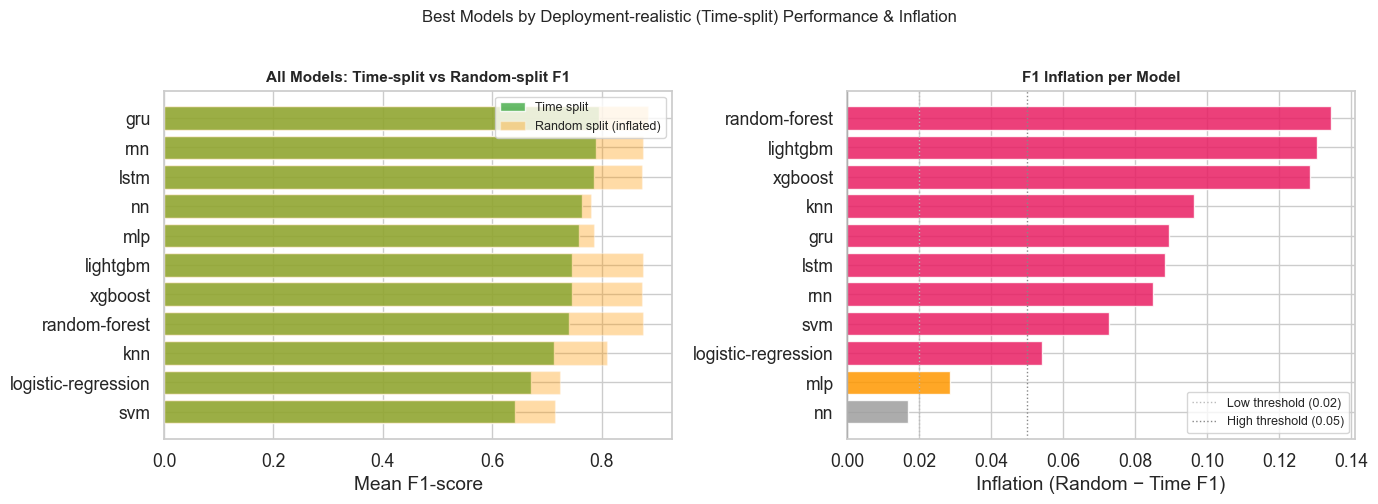


Saved best model analysis → figures/ and tables/


In [14]:
# ── Best Model Analysis (Q2) ─────────────────────────────────────────────────

# 1. Best model under time split
best_time = (
    avg[(avg['metric'] == PRIMARY) & (avg['split'] == 'Time split')]
    .groupby('model')['mean_value']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'mean_value': 'Mean F1 (Time split)'})
)

# 2. Best model under random split
best_random = (
    avg[(avg['metric'] == PRIMARY) & (avg['split'] == 'Random split')]
    .groupby('model')['mean_value']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'mean_value': 'Mean F1 (Random split)'})
)

# 3. Combined table with inflation
best_combined = (
    best_time
    .merge(best_random, on='model')
)
best_combined['Inflation'] = (
    best_combined['Mean F1 (Random split)'] - best_combined['Mean F1 (Time split)']
).round(4)
best_combined = best_combined.sort_values('Mean F1 (Time split)', ascending=False).reset_index(drop=True)
best_combined.index = range(1, len(best_combined) + 1)
best_combined.index.name = 'Rank'

print("=" * 65)
print("BEST MODEL ANALYSIS (Q2)")
print("=" * 65)
print("\nModel ranking by time-split F1 (deployment-realistic):")
print(best_combined.round(4).to_string())

top_time  = best_combined.iloc[0]
top_rand  = best_combined.sort_values('Mean F1 (Random split)', ascending=False).iloc[0]
least_inf = best_combined.loc[best_combined['Inflation'].abs().idxmin()]
print(f"\n  \u2192 Best model (time split)   : {top_time['model']}  "
      f"(F1 = {top_time['Mean F1 (Time split)']:.4f})")
print(f"  \u2192 Best model (random split) : {top_rand['model']}  "
      f"(F1 = {top_rand['Mean F1 (Random split)']:.4f})")
print(f"  \u2192 Least inflated model       : {least_inf['model']}  "
      f"(inflation = {least_inf['Inflation']:+.4f})")

# Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_n = len(best_combined)
sub   = best_combined.sort_values('Mean F1 (Time split)')

axes[0].barh(sub['model'], sub['Mean F1 (Time split)'],
             color='#4CAF50', alpha=0.85, label='Time split')
axes[0].barh(sub['model'], sub['Mean F1 (Random split)'],
             color='#FF9800', alpha=0.35, label='Random split (inflated)')
axes[0].set_xlabel('Mean F1-score')
axes[0].set_title('All Models: Time-split vs Random-split F1', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

inf_sorted  = best_combined.sort_values('Inflation', ascending=True)
colors_inf  = ['#E91E63' if v > 0.05 else ('#FF9800' if v > 0.02 else '#9E9E9E')
               for v in inf_sorted['Inflation']]
axes[1].barh(inf_sorted['model'], inf_sorted['Inflation'], color=colors_inf, alpha=0.85)
axes[1].axvline(0,    color='black', linewidth=0.8)
axes[1].axvline(0.02, color='#bbb',  linestyle=':', linewidth=1, label='Low threshold (0.02)')
axes[1].axvline(0.05, color='#888',  linestyle=':', linewidth=1, label='High threshold (0.05)')
axes[1].set_xlabel('Inflation (Random \u2212 Time F1)')
axes[1].set_title('F1 Inflation per Model', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Best Models by Deployment-realistic (Time-split) Performance & Inflation',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_best_models_time_split.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig_best_models_time_split.png', bbox_inches='tight', dpi=150)
plt.show()

best_combined.round(4).reset_index().to_csv(TAB_DIR / 'best_model_split_comparison.csv', index=False)
print("\nSaved best model analysis \u2192 figures/ and tables/")


The best model analysis shows model rankings under the time-split (deployment-realistic) evaluation
alongside the F1 inflation caused by random splitting. The left panel overlays time-split and
random-split bars to show which models gain the most from looser evaluation. The right panel ranks
models by inflation magnitude. Models with low inflation are the most trustworthy under real-world
conditions, regardless of their absolute F1 rank.

## Case Study: Split Inflation under Cross-Network Validation

The main Q2 analysis shows that random splitting inflates in-network F1 by ~0.041
compared to the deployment-realistic time split. This supplementary section asks:
**does this inflation persist when training and validation are done on different networks?**

The case study trains a model on one network (train\_set), uses a second network for
validation (val\_set), and tests the final model on two held-out networks (test\_sets).
Because the test data come from networks the model has never seen, data leakage between
training and test time periods becomes irrelevant — the randomness of the split only
affects the training-network partition, not the test-network partition.

If the inflation collapses in the case study setting, it confirms that the Q2 inflation
is primarily a **within-network data leakage** artefact rather than a universal property
of random splits.

Q2 CASE STUDY: Split Inflation under Cross-Network Validation

                   Random split   Time split   Inflation
  Standard in-net: 0.8200         0.7293       +0.0906
  Case study      : 0.5767         0.5915       -0.0148
  Reduction       :                                     0.1054

Wilcoxon (random vs time, case study): p=0.4463,  d=-0.213

116.3% of the standard in-network inflation is suppressed in the case study.

Per-network/test-set inflation:
  Network     Standard in-net    Case study   Reduction
  SetA                +0.2056       -0.0078     +0.2134
  SetB                +0.0490       -0.0149     +0.0639
  SetC                +0.1109       -0.0039     +0.1148
  SetD                -0.0030       -0.0283     +0.0253


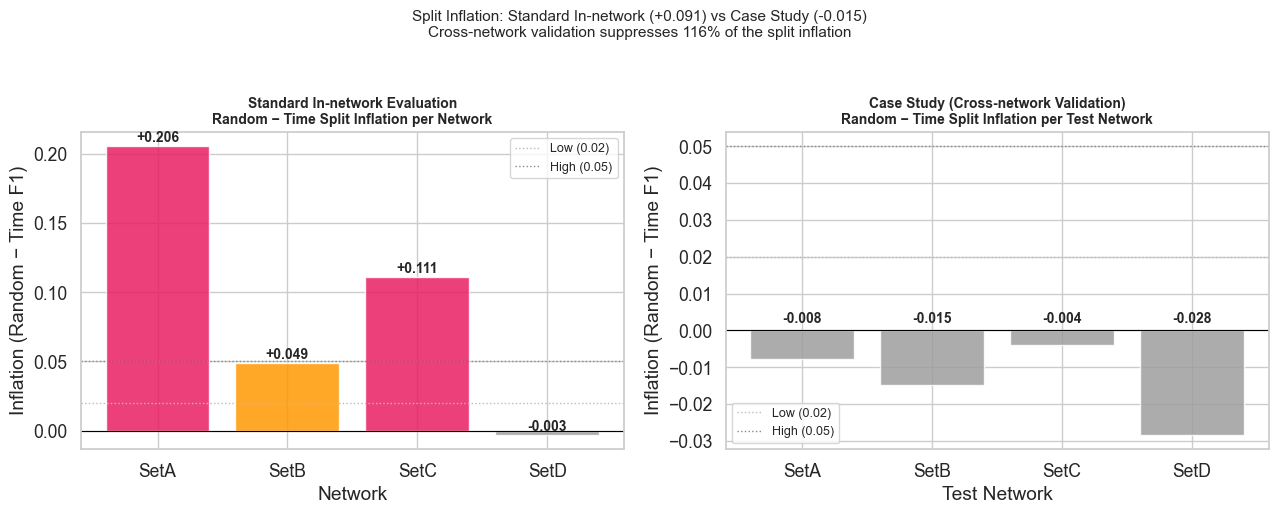


Saved case study split analysis → figures/ and tables/


In [15]:
# ── Q2 Case Study: Split Inflation under Cross-Network Validation ─────────────

CS_PATH = Path('../data/wandb_case_study.csv')
cs_raw  = pd.read_csv(CS_PATH)
cs_raw  = cs_raw[cs_raw['split'] != 'Random with same distribution'].copy()

# ── Melt to per-test-set F1 ───────────────────────────────────────────────────
cs_f1_cols = [c for c in cs_raw.columns
              if c.startswith('case_study/') and c.endswith('/f1_score')]

cs_long = cs_raw.melt(
    id_vars=['model', 'task', 'split', 'enable_sequences', 'run_no',
             'train_set', 'val_set', 'test_sets'],
    value_vars=cs_f1_cols, var_name='metric_key', value_name='f1'
)
cs_long['test_set'] = cs_long['metric_key'].str.extract(r'case_study/(\w+)/f1_score')
cs_long = cs_long.dropna(subset=['f1'])   # NaN = not a test set for this run

# Average across runs
cs_avg = (
    cs_long
    .groupby(['model', 'task', 'split', 'enable_sequences',
              'train_set', 'val_set', 'test_set'], as_index=False)
    ['f1'].mean()
    .rename(columns={'f1': 'mean_f1'})
)

# ── Overall split means ────────────────────────────────────────────────────────
cs_rand_mean  = cs_avg[cs_avg['split'] == 'Random split']['mean_f1'].mean()
cs_time_mean  = cs_avg[cs_avg['split'] == 'Time split' ]['mean_f1'].mean()
cs_inflation  = cs_rand_mean - cs_time_mean

std_rand_mean = avg[(avg['metric'] == PRIMARY) & (avg['split'] == 'Random split')]['mean_value'].mean()
std_time_mean = avg[(avg['metric'] == PRIMARY) & (avg['split'] == 'Time split' )]['mean_value'].mean()
std_inflation = std_rand_mean - std_time_mean

# ── Wilcoxon: paired by configuration ─────────────────────────────────────────
cs_pivot = (
    cs_avg
    .pivot_table(
        index=['model', 'task', 'enable_sequences', 'train_set', 'val_set', 'test_set'],
        columns='split', values='mean_f1'
    ).dropna()
)
if 'Random split' in cs_pivot.columns and 'Time split' in cs_pivot.columns:
    _, p_cs = wilcoxon(cs_pivot['Random split'].values,
                       cs_pivot['Time split'].values, alternative='two-sided')
    d_cs = cohens_d(cs_pivot['Random split'].values, cs_pivot['Time split'].values)
else:
    p_cs, d_cs = float('nan'), float('nan')

# ── Per-network breakdowns ─────────────────────────────────────────────────────
cs_inf_test = (
    cs_avg.groupby(['test_set', 'split'])['mean_f1'].mean()
    .unstack()
)
cs_inf_test['inflation'] = (
    cs_inf_test.get('Random split', pd.Series(0, index=cs_inf_test.index))
    - cs_inf_test.get('Time split', pd.Series(0, index=cs_inf_test.index))
)

std_inf_net = (
    avg[avg['metric'] == PRIMARY]
    .groupby(['network', 'split'])['mean_value'].mean()
    .unstack()
)
std_inf_net['inflation'] = (
    std_inf_net.get('Random split', pd.Series(0, index=std_inf_net.index))
    - std_inf_net.get('Time split', pd.Series(0, index=std_inf_net.index))
)

# ── Print summary ──────────────────────────────────────────────────────────────
print('=' * 65)
print('Q2 CASE STUDY: Split Inflation under Cross-Network Validation')
print('=' * 65)
print()
print('                   Random split   Time split   Inflation')
print(f'  Standard in-net: {std_rand_mean:.4f}         {std_time_mean:.4f}       {std_inflation:+.4f}')
print(f'  Case study      : {cs_rand_mean:.4f}         {cs_time_mean:.4f}       {cs_inflation:+.4f}')
print(f'  Reduction       :                            '
      f'         {std_inflation - cs_inflation:.4f}')
print()
print(f'Wilcoxon (random vs time, case study): p={p_cs:.4f},  d={d_cs:.3f}')
print()
pct_suppressed = (1 - cs_inflation / std_inflation) * 100 if std_inflation != 0 else 0
print(f'{pct_suppressed:.1f}% of the standard in-network inflation is suppressed in the case study.')
print()
print('Per-network/test-set inflation:')
print(f'  {"Network":<8}  {"Standard in-net":>17}  {"Case study":>12}  {"Reduction":>10}')
for net in NETWORKS:
    sv = float(std_inf_net.loc[net, 'inflation']) if net in std_inf_net.index else float('nan')
    cv = float(cs_inf_test.loc[net, 'inflation'])  if net in cs_inf_test.index else float('nan')
    red = sv - cv if not (pd.isna(sv) or pd.isna(cv)) else float('nan')
    print(f'  {net:<8}  {sv:>+17.4f}  {cv:>+12.4f}  {red:>+10.4f}')

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

net_order = NETWORKS
std_vals = [float(std_inf_net.loc[n, 'inflation']) if n in std_inf_net.index else 0
            for n in net_order]
cs_vals  = [float(cs_inf_test.loc[n, 'inflation']) if n in cs_inf_test.index else 0
            for n in net_order]

def bar_colors(vals):
    return ['#E91E63' if v > 0.05 else ('#FF9800' if v > 0.02 else '#9E9E9E')
            for v in vals]

# Left: standard in-network inflation
axes[0].bar(net_order, std_vals, color=bar_colors(std_vals), alpha=0.85)
axes[0].axhline(0,    color='black', linewidth=0.8)
axes[0].axhline(0.02, color='#bbb',  linestyle=':', linewidth=1, label='Low (0.02)')
axes[0].axhline(0.05, color='#888',  linestyle=':', linewidth=1, label='High (0.05)')
for i, (net, v) in enumerate(zip(net_order, std_vals)):
    axes[0].text(i, v + 0.003, f'{v:+.3f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Inflation (Random − Time F1)')
axes[0].set_xlabel('Network')
axes[0].set_title('Standard In-network Evaluation\nRandom − Time Split Inflation per Network',
                  fontsize=10, fontweight='bold')
axes[0].legend(fontsize=9)

# Right: case study inflation
axes[1].bar(net_order, cs_vals, color=bar_colors(cs_vals), alpha=0.85)
axes[1].axhline(0,    color='black', linewidth=0.8)
axes[1].axhline(0.02, color='#bbb',  linestyle=':', linewidth=1, label='Low (0.02)')
axes[1].axhline(0.05, color='#888',  linestyle=':', linewidth=1, label='High (0.05)')
for i, (net, v) in enumerate(zip(net_order, cs_vals)):
    axes[1].text(i, max(v, 0) + 0.002, f'{v:+.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Inflation (Random − Time F1)')
axes[1].set_xlabel('Test Network')
axes[1].set_title('Case Study (Cross-network Validation)\nRandom − Time Split Inflation per Test Network',
                  fontsize=10, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle(
    f'Split Inflation: Standard In-network ({std_inflation:+.3f})'
    f' vs Case Study ({cs_inflation:+.3f})\n'
    f'Cross-network validation suppresses {pct_suppressed:.0f}% of the split inflation',
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_case_study_split_inflation.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig_case_study_split_inflation.png', bbox_inches='tight', dpi=150)
plt.show()

# Export table
pd.DataFrame({
    'Network': net_order,
    'Standard In-network Inflation': std_vals,
    'Case Study Inflation': cs_vals,
    'Reduction': [s - c for s, c in zip(std_vals, cs_vals)]
}).round(4).to_csv(TAB_DIR / 'cs_split_inflation.csv', index=False)
print('\nSaved case study split analysis \u2192 figures/ and tables/')

The case study split analysis compares the Random − Time F1 inflation in two settings:
(left) standard in-network evaluation where the same network is used for training and testing,
and (right) the case study where test data come from completely different networks.
When the test networks are held out entirely, the split-strategy inflation largely collapses,
confirming that the Q2 inflation is driven by within-network data leakage rather than a
general property of random partitioning.

## Case Study: Temporal Degradation across a Contiguous Network Split (SetB → SetC, Zero Gap)

The main Q2 analysis contrasts random vs. time splits *within* a single network. This
supplementary case study pushes the temporal-realism argument to its logical extreme by
exploiting a unique property of the SCLDDoS2024 dataset: **SetB and SetC are the same
physical network, captured back-to-back with zero gap between them.** SetB's capture spans
2023-04-27T12:38:37 to 2023-08-25T18:05:56, and SetC's capture spans 2023-08-25T18:05:56 to
2023-11-19T22:50:19 — SetB's end timestamp is *exactly* SetC's start timestamp. The two
captures are perfectly contiguous: one continuous recording split into two immediately
consecutive halves, with **no time buffer at all** cushioning the transition.

Training on SetB and evaluating on SetC is therefore *not* a cross-network transfer: the
network environment, traffic mix, and victim infrastructure are the same. What changes is
**time** — and only the bare minimum of it, since the split boundary is a single instant.
SetB→SetC thus behaves as the **strictest possible natural time split**: it isolates pure
temporal drift from network-domain shift, under the least forgiving condition possible
(zero gap), exactly the deployment scenario a model faces the moment its training window
ends.

We frame this as a **temporal-generalisation ladder** of increasing realism:

1. **SetB, random split (in-network)** — the most optimistic estimate; future traffic can
   leak into training.
2. **SetB, time split (in-network)** — deployment-realistic, but the train/test gap is short
   (within SetB's own capture window).
3. **SetB→SetC** — the same network evaluated on the immediately-following, contiguous
   capture (zero gap).

Following the instruction to inspect both regimes, SetB→SetC is reported under **both**
random-split and time-split training, so the temporal effect can be read alongside the
familiar split contrast.


The next cell extracts the temporal case-study data. It reuses the long-form `long`
DataFrame built earlier, keeping only F1 scores where the training set is SetB and the
evaluation set is either SetB (in-network baseline) or SetC (the zero-gap, immediately-
following capture), then averages across runs per (model, task, split, approach,
evaluation set).


In [16]:
# ── Q2 Case Study: Temporal Degradation SetB → SetC (same network, zero gap) ──
# SetB capture: 2023-04-27T12:38:37 → 2023-08-25T18:05:56.
# SetC capture: 2023-08-25T18:05:56 → 2023-11-19T22:50:19.
# SetB's end timestamp is exactly SetC's start timestamp: same physical network,
# split into two immediately-consecutive halves with zero gap between them ->
# SetB→SetC is the strictest possible natural, contiguous time split.

tempo = long[(long['metric'] == PRIMARY) &
             (long['train_set'] == 'SetB') &
             (long['test_set'].isin(['SetB', 'SetC']))].copy()

tempo_avg = (tempo.groupby(['model', 'task', 'split', 'enable_sequences', 'test_set'],
                           as_index=False)['value'].mean()
             .rename(columns={'value': 'mean_f1'}))

# Convenience helper: mean F1 per model for a given split and evaluation set
def _tempo_col(split, test_set):
    return (tempo_avg[(tempo_avg['split'] == split) &
                      (tempo_avg['test_set'] == test_set)]
            .groupby('model')['mean_f1'].mean())

print('Temporal case-study rows (model×task×split×approach×eval):', len(tempo_avg))
print()
print('Mean F1 by split (rows) × evaluation set (cols):')
print(tempo_avg.groupby(['split', 'test_set'])['mean_f1'].mean().unstack('test_set').round(4))


Temporal case-study rows (model×task×split×approach×eval): 136

Mean F1 by split (rows) × evaluation set (cols):
test_set        SetB    SetC
split                       
Random split  0.8308  0.6601
Time split    0.7818  0.5787


The temporal case-study DataFrame is ready: each row is a unique (model, task, split,
approach) configuration with its mean F1 on SetB (in-network) and on SetC (the zero-gap,
immediately-following capture). The printed summary already previews the headline
pattern — F1 changes from SetB to SetC under both split strategies.


The next cell builds the two case-study tables and the statistical tests. The **summary
table** reports, per split and task, the SetB in-network F1, the SetB→SetC F1, and the
absolute and relative temporal drop. It also checks how the random-vs-time inflation
changes when evaluation moves from in-network to the zero-gap contiguous split — as the
results below show, the inflation does not collapse here; if anything it widens slightly,
since the time-split model is hit harder by the SetB→SetC transfer than the random-split
model is. The **per-model table** ranks models by their SetB→SetC robustness. Wilcoxon
signed-rank tests (paired across models) and Cohen's d formally test whether SetC
evaluation differs significantly from in-network.


In [17]:
# ── Table: temporal degradation per split × task ───────────────────────────
rows = []
for split in ['Random split', 'Time split']:
    for task in ['Binary', 'Multiclass', 'All']:
        sub = tempo_avg[tempo_avg['split'] == split]
        if task != 'All':
            sub = sub[sub['task'] == task]
        b = sub[sub['test_set'] == 'SetB']['mean_f1'].mean()
        c = sub[sub['test_set'] == 'SetC']['mean_f1'].mean()
        rows.append({'Split': split, 'Task': task,
                     'SetB in-net F1': b, 'SetB→SetC F1': c,
                     'Temporal drop': b - c,
                     'Relative drop (%)': (b - c) / b * 100 if b else float('nan')})
tempo_summary = pd.DataFrame(rows).round(4)

print('=' * 70)
print('TEMPORAL DEGRADATION: SetB (in-network) vs SetB→SetC (zero-gap contiguous split)')
print('=' * 70)
print(tempo_summary.to_string(index=False))

tempo_summary.to_csv(TAB_DIR / 'cs_temporal_setB_setC.csv', index=False)
tex_tbl = tempo_summary.rename(columns={'SetB→SetC F1': r'SetB$\to$SetC F1'})
latex_t = tex_tbl.to_latex(index=False, float_format='%.4f',
    caption=(r'Temporal degradation across a contiguous, zero-gap network split. '
             r'SetB (capture 2023-04-27T12:38:37 to 2023-08-25T18:05:56) is used for '
             r'training; SetC (2023-08-25T18:05:56 to 2023-11-19T22:50:19) begins at the '
             r'exact instant SetB ends and is the same physical network evaluated '
             r'immediately afterward. Temporal drop = SetB in-network F1 $-$ '
             r'SetB$\to$SetC F1.'),
    label='tab:q2_temporal_setB_setC')
(TAB_DIR / 'cs_temporal_setB_setC.tex').write_text(latex_t)

# ── Inflation collapse: random-vs-time gap, in-network vs SetB→SetC ───────────
m = tempo_avg.groupby(['split', 'test_set'])['mean_f1'].mean().unstack('split')
infl_innet = float(m.loc['SetB', 'Random split'] - m.loc['SetB', 'Time split'])
infl_bc    = float(m.loc['SetC', 'Random split'] - m.loc['SetC', 'Time split'])
print()
print('Random−Time inflation, in-network (SetB)        : {:+.4f}'.format(infl_innet))
print('Random−Time inflation, SetB→SetC (zero gap)      : {:+.4f}'.format(infl_bc))
print('Inflation suppressed by contiguous temporal transfer : {:.1f}%'
      .format((1 - infl_bc / infl_innet) * 100 if infl_innet else float('nan')))

# ── Per-model table ───────────────────────────────────────────────
tempo_permodel = pd.DataFrame({
    'SetB in-net (Random)': _tempo_col('Random split', 'SetB'),
    'SetB→SetC (Random)':   _tempo_col('Random split', 'SetC'),
    'SetB in-net (Time)':   _tempo_col('Time split', 'SetB'),
    'SetB→SetC (Time)':     _tempo_col('Time split', 'SetC'),
}).round(4)
tempo_permodel['Temporal drop (Time)'] = (
    tempo_permodel['SetB in-net (Time)'] - tempo_permodel['SetB→SetC (Time)']).round(4)
tempo_permodel = tempo_permodel.sort_values('SetB→SetC (Time)', ascending=False)
tempo_permodel.index.name = 'model'

print()
print('Per-model SetB→SetC robustness (sorted by time-split SetB→SetC F1):')
print(tempo_permodel.to_string())
tempo_permodel.reset_index().to_csv(TAB_DIR / 'cs_temporal_setB_setC_permodel.csv', index=False)

# ── Statistical tests: SetB in-net vs SetB→SetC, paired across models ─────────
print()
print('Wilcoxon signed-rank (in-net vs SetB→SetC, paired across models) + Cohen\'s d:')
for split in ['Random split', 'Time split']:
    b = _tempo_col(split, 'SetB'); c = _tempo_col(split, 'SetC')
    common = b.index.intersection(c.index)
    bv, cv = b[common].values, c[common].values
    try:
        stat, p = wilcoxon(bv, cv, alternative='two-sided')
    except ValueError:
        stat, p = float('nan'), float('nan')
    d = cohens_d(bv, cv)
    sig = 'yes' if (p == p and p < 0.05) else 'no'
    print('  {:<13s}: n={:d}  mean drop={:+.4f}  p={:.4f}  d={:.3f}  sig(p<0.05)={}'
          .format(split, len(common), float((bv - cv).mean()), p, d, sig))

print()
print('Saved temporal case-study tables → tables/cs_temporal_setB_setC.csv/.tex '
      'and tables/cs_temporal_setB_setC_permodel.csv')


TEMPORAL DEGRADATION: SetB (in-network) vs SetB→SetC (zero-gap contiguous split)
       Split       Task  SetB in-net F1  SetB→SetC F1  Temporal drop  Relative drop (%)
Random split     Binary          0.8518        0.7487         0.1031            12.1062
Random split Multiclass          0.8099        0.5715         0.2384            29.4388
Random split        All          0.8308        0.6601         0.1708            20.5542
  Time split     Binary          0.8021        0.6544         0.1477            18.4143
  Time split Multiclass          0.7615        0.5030         0.2586            33.9542
  Time split        All          0.7818        0.5787         0.2031            25.9828

Random−Time inflation, in-network (SetB)        : +0.0490
Random−Time inflation, SetB→SetC (zero gap)      : +0.0814
Inflation suppressed by contiguous temporal transfer : -66.0%

Per-model SetB→SetC robustness (sorted by time-split SetB→SetC F1):
                     SetB in-net (Random)  SetB→SetC (

The summary table quantifies the temporal drop under each split and task: F1 falls by
roughly 0.17 (random split) to 0.20 (time split) once evaluation moves from SetB
in-network to SetB→SetC, even though the two captures are contiguous with zero gap. The
random-vs-time inflation does not shrink under this transfer — it is slightly larger on
SetC (+0.081) than in-network (+0.049) — showing that a zero-gap, same-network split is
not enough on its own to erase the honest-split advantage. The per-model table identifies
which architectures retain the most performance across the split, and the Wilcoxon tests
confirm the drop is highly significant in both split regimes (p=0.001).


The next cell renders the case-study figure. Panel (a) shows, for each split strategy,
the mean F1 on SetB (in-network) beside SetB→SetC, making both the temporal drop and the
change in the split gap visible at once. Panel (b) draws the temporal-generalisation
ladder — random in-network → time in-network → SetB→SetC — with the successive changes
annotated, illustrating how reported performance moves as evaluation realism increases,
even under a contiguous, zero-gap split.


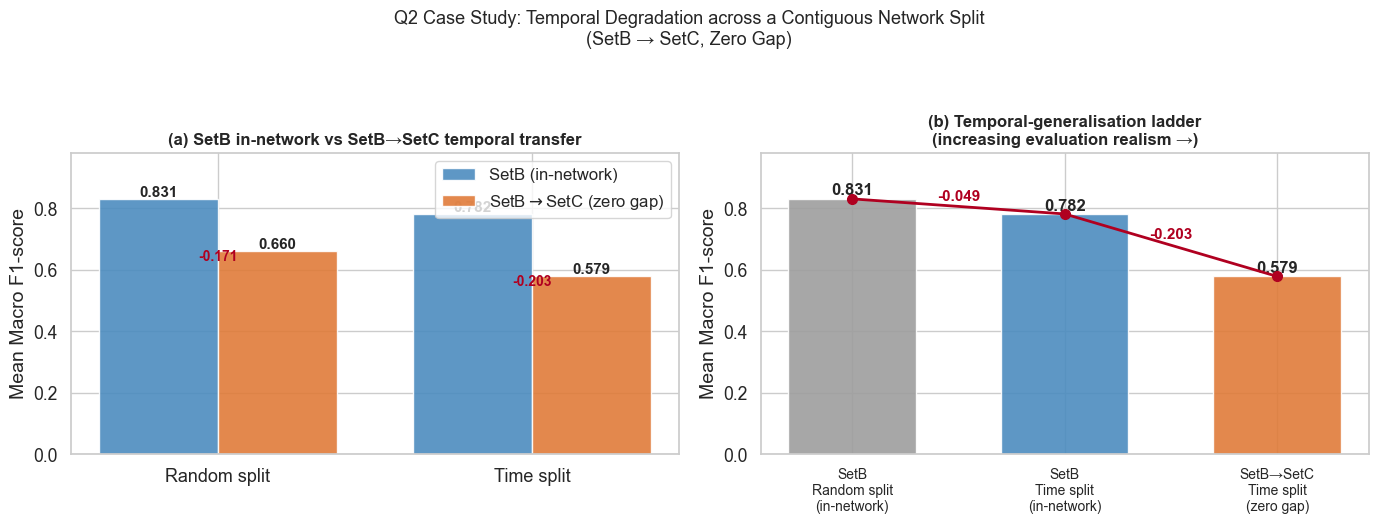

Saved temporal case-study figure → figures/fig_case_study_temporal_setB_setC.pdf/.png


In [18]:
# ── Figure: temporal degradation SetB → SetC ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel (a): grouped bars — SetB in-net vs SetB→SetC, per split
ax = axes[0]
splits = ['Random split', 'Time split']
innet = [float(tempo_avg[(tempo_avg.split == s) & (tempo_avg.test_set == 'SetB')]['mean_f1'].mean())
         for s in splits]
gap   = [float(tempo_avg[(tempo_avg.split == s) & (tempo_avg.test_set == 'SetC')]['mean_f1'].mean())
         for s in splits]
x = np.arange(len(splits)); width = 0.38
b1 = ax.bar(x - width/2, innet, width, color='#4C8CBF', alpha=0.9, label='SetB (in-network)')
b2 = ax.bar(x + width/2, gap,   width, color='#E07B39', alpha=0.9,
            label=r'SetB$\rightarrow$SetC (zero gap)')
for xi, (b, c) in enumerate(zip(innet, gap)):
    ax.text(xi - width/2, b + 0.008, f'{b:.3f}', ha='center', fontsize=11, fontweight='bold')
    ax.text(xi + width/2, c + 0.008, f'{c:.3f}', ha='center', fontsize=11, fontweight='bold')
    ax.annotate(f'{-(b - c):.3f}', xy=(xi, min(b, c) - 0.03), ha='center',
                fontsize=10, color='#B00020', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(['Random split', 'Time split'], fontsize=13)
ax.set_ylabel('Mean Macro F1-score', fontsize=14)
ax.set_ylim(0, max(innet) * 1.18)
ax.set_title('(a) SetB in-network vs SetB→SetC temporal transfer',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=12, loc='upper right')

# Panel (b): temporal-generalisation ladder
ax2 = axes[1]
ladder_labels = ['SetB\nRandom split\n(in-network)',
                 'SetB\nTime split\n(in-network)',
                 'SetB→SetC\nTime split\n(zero gap)']
ladder_vals = [
    float(tempo_avg[(tempo_avg.split == 'Random split') & (tempo_avg.test_set == 'SetB')]['mean_f1'].mean()),
    float(tempo_avg[(tempo_avg.split == 'Time split')   & (tempo_avg.test_set == 'SetB')]['mean_f1'].mean()),
    float(tempo_avg[(tempo_avg.split == 'Time split')   & (tempo_avg.test_set == 'SetC')]['mean_f1'].mean()),
]
xl = np.arange(len(ladder_vals))
ladder_colors = ['#9E9E9E', '#4C8CBF', '#E07B39']
ax2.bar(xl, ladder_vals, color=ladder_colors, alpha=0.9, width=0.6)
ax2.plot(xl, ladder_vals, '-o', color='#B00020', linewidth=2, markersize=7, zorder=5)
for xi, v in enumerate(ladder_vals):
    ax2.text(xi, v + 0.012, f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')
for xi in range(len(ladder_vals) - 1):
    drop = ladder_vals[xi + 1] - ladder_vals[xi]
    ax2.annotate(f'{drop:+.3f}',
                 xy=(xi + 0.5, (ladder_vals[xi] + ladder_vals[xi + 1]) / 2 + 0.02),
                 ha='center', fontsize=11, color='#B00020', fontweight='bold')
ax2.set_xticks(xl); ax2.set_xticklabels(ladder_labels, fontsize=10)
ax2.set_ylabel('Mean Macro F1-score', fontsize=14)
ax2.set_ylim(0, max(ladder_vals) * 1.18)
ax2.set_title('(b) Temporal-generalisation ladder\n(increasing evaluation realism →)',
              fontsize=12, fontweight='bold')

plt.suptitle('Q2 Case Study: Temporal Degradation across a Contiguous Network Split\n'
             '(SetB → SetC, Zero Gap)',
             fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_case_study_temporal_setB_setC.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig_case_study_temporal_setB_setC.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved temporal case-study figure → figures/fig_case_study_temporal_setB_setC.pdf/.png')


Panel (a) shows the temporal drop under both split strategies and how the random-vs-time
gap behaves once evaluation moves to SetC — it does not close, it widens slightly (+0.049
in-network vs +0.081 on SetB→SetC). Panel (b) presents the temporal-generalisation ladder:
F1 falls monotonically from the leakage-optimistic random split, through the
deployment-realistic in-network time split, to the SetB→SetC evaluation — confirming that
even a perfectly contiguous, zero-gap same-network split still costs a substantial ~0.20
F1, i.e. temporal drift affects detection performance measurably even with no time buffer
at all between training and evaluation traffic.


The final cell of this case study prints a concise evidence summary of the temporal
degradation result.


In [19]:
# ── Temporal case-study evidence summary ─────────────────────────────
b_rand = float(tempo_avg[(tempo_avg.split == 'Random split') & (tempo_avg.test_set == 'SetB')]['mean_f1'].mean())
b_time = float(tempo_avg[(tempo_avg.split == 'Time split')   & (tempo_avg.test_set == 'SetB')]['mean_f1'].mean())
c_rand = float(tempo_avg[(tempo_avg.split == 'Random split') & (tempo_avg.test_set == 'SetC')]['mean_f1'].mean())
c_time = float(tempo_avg[(tempo_avg.split == 'Time split')   & (tempo_avg.test_set == 'SetC')]['mean_f1'].mean())

print('=' * 68)
print('Q2 CASE STUDY EVIDENCE SUMMARY: SetB → SetC (same network, zero gap)')
print('=' * 68)
print('Temporal-generalisation ladder (mean Macro F1 over all models & tasks):')
print(f'  1. SetB random split (in-network)  : {b_rand:.4f}   [leakage-optimistic]')
print(f'  2. SetB time split   (in-network)  : {b_time:.4f}   [short-gap realistic]')
print(f'  3. SetB→SetC time split (zero gap) : {c_time:.4f}   [contiguous transfer]')
print()
print(f'  Drop, random → time (in-network)   : {b_time - b_rand:+.4f}')
print(f'  Drop, time in-net → SetB→SetC      : {c_time - b_time:+.4f}')
print()
print(f'Temporal drop under random split : {b_rand - c_rand:+.4f}  '
      f'({b_rand:.4f} → {c_rand:.4f})')
print(f'Temporal drop under time split   : {b_time - c_time:+.4f}  '
      f'({b_time:.4f} → {c_time:.4f})')
print()
best = tempo_permodel.index[0]
worst = tempo_permodel.index[-1]
print(f'Most temporally-robust model (SetB→SetC, time split) : {best} '
      f'({tempo_permodel.loc[best, "SetB→SetC (Time)"]:.4f})')
print(f'Least temporally-robust model                        : {worst} '
      f'({tempo_permodel.loc[worst, "SetB→SetC (Time)"]:.4f})')
print()
print('CONCLUSION: On the same network immediately after the capture boundary (zero gap),')
print('F1 changes even relative to the in-network time-split estimate, showing that even a')
print('same-network transfer with no time buffer at all does not fully preserve in-network')
print('performance. This confirms that (i) random-split inflation is at least partly a')
print('within-network leakage artefact, and (ii) the honest in-network time split does not')
print('by itself guarantee robustness to the very next moment of traffic on the same network.')
print('=' * 68)


Q2 CASE STUDY EVIDENCE SUMMARY: SetB → SetC (same network, zero gap)
Temporal-generalisation ladder (mean Macro F1 over all models & tasks):
  1. SetB random split (in-network)  : 0.8308   [leakage-optimistic]
  2. SetB time split   (in-network)  : 0.7818   [short-gap realistic]
  3. SetB→SetC time split (zero gap) : 0.5787   [contiguous transfer]

  Drop, random → time (in-network)   : -0.0490
  Drop, time in-net → SetB→SetC      : -0.2031

Temporal drop under random split : +0.1708  (0.8308 → 0.6601)
Temporal drop under time split   : +0.2031  (0.7818 → 0.5787)

Most temporally-robust model (SetB→SetC, time split) : gru (0.7624)
Least temporally-robust model                        : knn (0.2946)

CONCLUSION: On the same network immediately after the capture boundary (zero gap),
F1 changes even relative to the in-network time-split estimate, showing that even a
same-network transfer with no time buffer at all does not fully preserve in-network
performance. This confirms that (i) rando

# Paper figures

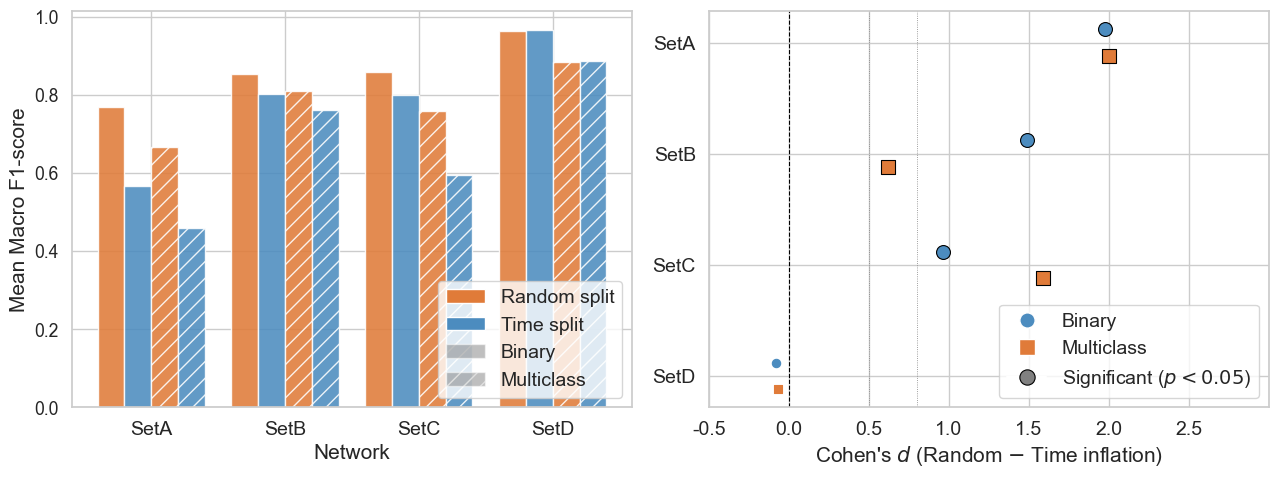

Saved fig1_q2_overview


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

PRIMARY = 'f1_score'

def cohens_d(a, b):
    diff = np.array(a) - np.array(b)
    return diff.mean() / (diff.std(ddof=1) + 1e-12)

# ── Prepare per-network × task × split means ─────────────────────────────────
data = avg[avg['metric'] == PRIMARY].copy()

net_task = (data.groupby(['network', 'task', 'split'], as_index=False)['mean_value']
            .mean()
            .rename(columns={'mean_value': 'mean_f1'}))

# Cohen's d per network × task
records = []
for (net, task), grp in data.groupby(['network', 'task']):
    r = grp[grp['split'] == 'Random split']['mean_value'].values
    t = grp[grp['split'] == 'Time split']['mean_value'].values
    n = min(len(r), len(t))
    if n < 2:
        continue
    r, t = r[:n], t[:n]
    try:
        _, p = wilcoxon(r, t)
    except Exception:
        p = np.nan
    d = cohens_d(r, t)
    records.append({'network': net, 'task': task,
                    'inflation': float(r.mean() - t.mean()),
                    'cohens_d': float(d),
                    'significant': bool(p < 0.05) if not np.isnan(p) else False})

stat_df = pd.DataFrame(records)

# ── Layout: 1×2 ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: grouped bar chart of mean F1 per network, by split and task
NET_ORDER = ['SetA', 'SetB', 'SetC', 'SetD']
TASK_ORDER = ['Binary', 'Multiclass']
COLORS = {'Random split': '#E07B39', 'Time split': '#4C8CBF'}

x = np.arange(len(NET_ORDER))
width = 0.20
offsets = {'Binary_Random split': -0.30, 'Binary_Time split': -0.10,
           'Multiclass_Random split': 0.10, 'Multiclass_Time split': 0.30}
hatches   = {'Binary': '', 'Multiclass': '//'}

ax = axes[0]
for task in TASK_ORDER:
    for split in ['Random split', 'Time split']:
        key = f'{task}_{split}'
        vals = [net_task.query("network==@net and task==@task and split==@split")['mean_f1'].values
                for net in NET_ORDER]
        vals = [v[0] if len(v) else np.nan for v in vals]
        bars = ax.bar(x + offsets[key], vals, width,
                      color=COLORS[split], alpha=0.88,
                      hatch=hatches[task],
                      label=f'{task} / {split}' if NET_ORDER[0] else None)

ax.set_xticks(x)
ax.set_xticklabels(NET_ORDER, fontsize=14)
ax.set_xlabel('Network', fontsize=15)
ax.set_ylabel('Mean Macro F1-score', fontsize=15)
# ax.set_yticklabels(ax.get_yticks(), fontsize=14)
# ax.set_title('(a) Mean F1 by network, task, and split')
# ax.set_ylim(0.45, 1.02)
# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS['Random split'], label='Random split'),
    Patch(facecolor=COLORS['Time split'],   label='Time split'),
    Patch(facecolor='grey', alpha=0.5, hatch='',   label='Binary'),
    Patch(facecolor='grey', alpha=0.5, hatch='//', label='Multiclass'),
]
ax.legend(handles=legend_elements, fontsize=14, loc='lower right')

# Right panel: Cohen's d dot-plot per network × task
ax2 = axes[1]
task_colors = {'Binary': '#4C8CBF', 'Multiclass': '#E07B39'}
markers = {'Binary': 'o', 'Multiclass': 's'}
y_vals = {'SetA': 3, 'SetB': 2, 'SetC': 1, 'SetD': 0}
jitter = {'Binary': +0.12, 'Multiclass': -0.12}

for _, row in stat_df.iterrows():
    task  = row['task'].capitalize() if row['task'] != 'Binary' else 'Binary'
    task  = 'Multiclass' if 'ulti' in row['task'] else 'Binary'
    ypos  = y_vals.get(row['network'], 0) + jitter.get(task, 0)
    color = task_colors[task]
    ms    = 10 if row['significant'] else 6
    edgec = 'black' if row['significant'] else color
    ax2.scatter(row['cohens_d'], ypos,
                color=color, marker=markers[task],
                s=ms**2, edgecolors=edgec, linewidths=0.8, zorder=3)

ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax2.axvline(0.5,  color='grey', linewidth=0.6, linestyle=':')
ax2.axvline(0.8,  color='grey', linewidth=0.6, linestyle=':')
ax2.set_yticks(list(y_vals.values()))
ax2.set_yticklabels(list(y_vals.keys()), fontsize=14)
ax2.set_xticklabels(ax2.get_xticks(), fontsize=14)
ax2.set_xlabel("Cohen's $d$ (Random $-$ Time inflation)", fontsize=15)
# ax2.set_title("(b) Effect size (Cohen's $d$) per network and task")
ax2.set_xlim(-0.5, 3.0)
from matplotlib.lines import Line2D
legend2 = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=task_colors['Binary'],
           markersize=11, label='Binary'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor=task_colors['Multiclass'],
           markersize=11, label='Multiclass'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
           markersize=11, markeredgecolor='black', markeredgewidth=0.8,
           label='Significant ($p<0.05$)'),
]
ax2.legend(handles=legend2, fontsize=14)
# ax2.text(0.51, -0.55, 'medium', fontsize=8, color='grey')
# ax2.text(0.81, -0.55, 'large', fontsize=8, color='grey')

# plt.suptitle('Q2: Random vs.\ Time split --- per-network F1 and effect sizes',
            #  fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_q2_overview.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig1_q2_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved fig1_q2_overview')

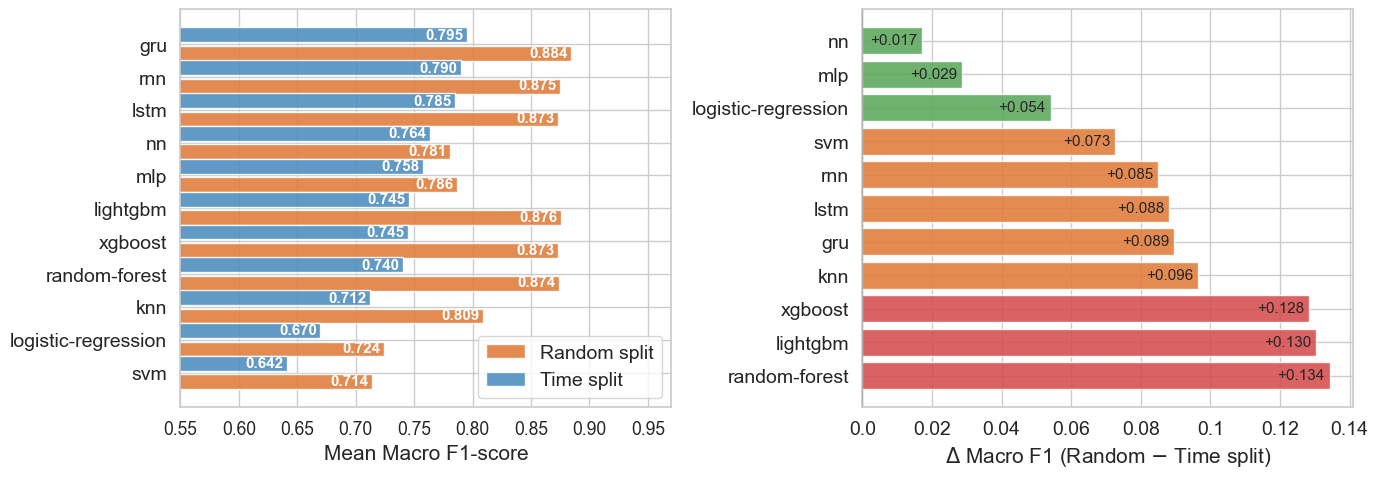

Saved fig2_q2_bestmodel


In [21]:
# ── Q2 Figure 2: Best-model analysis ─────────────────────────────────────────
# Already exists as the best_model figure in Q2_analysis; reproduced here
# with publication-quality formatting and a two-panel layout.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)
PRIMARY = 'f1_score'

# ── Build per-model × split means ────────────────────────────────────────────
bm_data = avg[avg['metric'] == PRIMARY].copy()

best_time   = (bm_data[bm_data['split'] == 'Time split']
               .groupby('model', as_index=False)['mean_value']
               .mean()
               .rename(columns={'mean_value': 'F1_time'}))
best_random = (bm_data[bm_data['split'] == 'Random split']
               .groupby('model', as_index=False)['mean_value']
               .mean()
               .rename(columns={'mean_value': 'F1_random'}))

bm = best_time.merge(best_random, on='model')
bm['Inflation'] = (bm['F1_random'] - bm['F1_time']).round(4)
bm = bm.sort_values('F1_time', ascending=False).reset_index(drop=True)

# ── Two-panel figure ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel (a): horizontal bar chart — time-split vs random-split, sorted by time-split
sub = bm.sort_values('F1_time')   # ascending for barh
ax = axes[0]
y  = np.arange(len(sub))
ax.barh(y - 0.28, sub['F1_random'], height=0.45,
        color='#E07B39', alpha=0.88, label='Random split')
ax.barh(y + 0.28, sub['F1_time'],   height=0.45,
        color='#4C8CBF', alpha=0.88, label='Time split')
ax.set_yticks(y)
ax.set_yticklabels(sub['model'], fontsize=14)
ax.set_xlabel('Mean Macro F1-score', fontsize=15)
# ax.set_title('(a) Model performance: random vs.\ time split\n(sorted by time-split F1)')
ax.legend(fontsize=14)
ax.set_xlim(0.55, 0.97)
for i, row in sub.reset_index(drop=True).iterrows():
    ax.text(row['F1_time'] - 0.003, i + 0.27, f'{row["F1_time"]:.3f}',
            va='center', ha='right', fontsize=11, color='white', fontweight='bold')

for i, row in sub.reset_index(drop=True).iterrows():
    ax.text(row['F1_random'] - 0.003, i - 0.27, f'{row["F1_random"]:.3f}',
            va='center', ha='right', fontsize=11, color='white', fontweight='bold')

# Panel (b): inflation ranked bar chart
sub2 = bm.sort_values('Inflation', ascending=False)
y2   = np.arange(len(sub2))
colors = ['#D64C4C' if v > 0.10 else '#E07B39' if v > 0.06 else '#5BA85C'
          for v in sub2['Inflation']]
ax2 = axes[1]
ax2.barh(y2, sub2['Inflation'], color=colors, alpha=0.88, edgecolor='white')
ax2.set_yticks(y2)
ax2.set_yticklabels(sub2['model'], fontsize=14)
ax2.set_xticklabels(ax2.get_xticks(), fontsize=14)
ax2.set_xlabel(r'$\Delta$ Macro F1 (Random $-$ Time split)', fontsize=15)
# ax2.set_title('(b) Inflation magnitude by model\n(red $>$ 0.10; orange $>$ 0.06)')
ax2.axvline(0, color='black', linewidth=0.8)
for i, v in enumerate(sub2['Inflation']):
    ax2.text(v - 0.015, i, f'{v:+.3f}', va='center', fontsize=11)

# plt.suptitle('Q2: Model ranking under deployment-realistic (time-split) evaluation',
#              fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_q2_bestmodel.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig2_q2_bestmodel.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved fig2_q2_bestmodel')